In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.reset_option('display.max_colwidth')

<h3>Kiểm tra cấu trúc tổng quan</h3>

In [36]:
ankhang_df = pd.read_csv(r'D:\OU\KhoaLuanTotNghiep\DrugRecommandation\crawlData_AnKhang\ankhang_medicines_data_demo.csv')
print(f"Số dòng: {ankhang_df.shape[0]}, Số cột: {ankhang_df.shape[1]}")
ankhang_df.info()
ankhang_df.head()

Số dòng: 2127, Số cột: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2127 entries, 0 to 2126
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ten_thuoc            2073 non-null   object
 1   gia                  521 non-null    object
 2   hinh_anh             2070 non-null   object
 3   cong_dung_tom_tat    2073 non-null   object
 4   thanh_phan_chinh     2007 non-null   object
 5   doi_tuong            1768 non-null   object
 6   thuong_hieu          2072 non-null   object
 7   noi_san_xuat         2073 non-null   object
 8   dang_bao_che         2073 non-null   object
 9   han_dung             2054 non-null   object
 10  thanh_phan_chi_tiet  2072 non-null   object
 11  cong_dung_chi_tiet   2043 non-null   object
 12  cach_dung            2058 non-null   object
 13  chong_chi_dinh       2040 non-null   object
 14  tac_dung_phu         1989 non-null   object
 15  luu_y                916 non-

,ten_thuoc,gia,hinh_anh,cong_dung_tom_tat,thanh_phan_chinh,doi_tuong,thuong_hieu,noi_san_xuat,dang_bao_che,han_dung,thanh_phan_chi_tiet,cong_dung_chi_tiet,cach_dung,chong_chi_dinh,tac_dung_phu,luu_y,url,category,drug_type,error
0,"Timi Roitin trị viêm dây thần kinh, thoái hóa ...",528.000₫,https://cdn.tgdd.vn/Products/Images/10053/1304...,"Bổ sung vitamin nhóm B, điều trị viêm dây thần...","Chondroitin, Vitamin B5, Fursultiamine, Vitami...",Người lớn,Phil Inter Pharma,Việt Nam,Viên nang mềm,36 tháng kể từ ngày sản xuất,"Hoạt chất: Chondroitin sulfate natri 90mg, Nic...",- Bổ sung các vitamin nhóm B trong các trường ...,Người lớn: Uống 1 viên/ngày.\n- Quá liều\nDùng...,- Quá mẫn với bất cứ thành phần nào của thuốc....,TIMIROITIN thường được dung nạp tốt khi dùng ở...,- Thận trọng khi sử dụng\n- Khi sử dụng nicoti...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN
1,B Complex C bổ sung vitamin nhóm B và vitamin ...,800₫,https://cdn.tgdd.vn/Products/Images/10053/1295...,Dự phòng & bổ sung khi thiếu hụt các vitamin n...,"Vitamin PP, Vitamin C, Vitamin B6, Vitamin B2,...",NaN,Vidipha,Việt Nam,Viên nang cứng,24 tháng kể từ ngày sản xuất,"Hoạt chất: Vitamin B1 15mg, Vitamin B2 10mg, V...",B Complex C dự phòng và bổ sung thiếu hụt các ...,Liều lượng: Trung bình: 1 - 2 viên/ngày.\nCách...,Dị ứng với một trong các thành phần của thuốc....,Dùng liều cao nước tiểu sẽ có màu vàng nhạt (d...,- Thận trọng khi sử dụng\nKhi sử dụng nicotina...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,NaN,NaN,Message: no such element: Unable to locate ele...
3,Vitamin PP 50 Pharmedic ngăn ngừa thiếu nicoti...,12.000₫,https://cdn.tgdd.vn/Products/Images/10053/1533...,Bổ sung vào khẩu phần ăn để ngăn ngừa thiếu hụ...,Vitamin PP,Người lớn và trẻ em trên 5 tuổi,Pharmedic,Việt Nam,Viên nén,NaN,Nicotinamid 50mg.\nTá dược 1 viên.,Vitamin PP 50 giúp bổ sung vào khẩu phần ăn để...,"Người lớn: mỗi lần 1 - 2 viên, ngày 3 lần.\nTr...","- Dị ứng với nicotinamid.\n- Bệnh gan nặng, lo...",NaN,- Thận trọng khi sử dụng\nNgười có tiền sử loé...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN
4,"Agi-Calci bổ sung canxi, trị loãng xương (20 v...",150.000₫,https://cdn.tgdd.vn/Products/Images/10053/2463...,Bổ sung calci khi thiếu hay tăng nhu cầu calci...,"Calci cacbonat, Vitamin D3",NaN,Agimexpharm,Việt Nam,Viên nén bao phim,24 tháng kể từ ngày sản xuất,Mỗi viên nén bao phim chứa:\nHoạt chất: Calci ...,- Agi-Calci bổ sung calci trong các trường hợp...,Uống thuốc buổi sáng hoặc buổi trưa theo liều ...,"- Tăng calci huyết, calci niệu, sỏi calci, suy...",- Dùng thuốc chứa muối calci qua đường uống có...,- Thận trọng khi sử dụng\nThận trọng khi sử dụ...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN


<h3>Kiểm tra giá trị thiếu</h3>

In [37]:
# Kiểm tra giá trị thiếu ở mỗi cột
missing_values = ankhang_df.isnull().sum()
print("Số lượng giá trị thiếu ở mỗi cột:")
print(missing_values)

# Kiểm tra giá trị thiếu tính theo phần trăm
missing_percentage = round((ankhang_df.isnull().sum() / len(ankhang_df)) * 100, 2)
print("\nPhần trăm giá trị thiếu ở mỗi cột:") 
print(missing_percentage)


Số lượng giá trị thiếu ở mỗi cột:
ten_thuoc                54
gia                    1606
hinh_anh                 57
cong_dung_tom_tat        54
thanh_phan_chinh        120
doi_tuong               359
thuong_hieu              55
noi_san_xuat             54
dang_bao_che             54
han_dung                 73
thanh_phan_chi_tiet      55
cong_dung_chi_tiet       84
cach_dung                69
chong_chi_dinh           87
tac_dung_phu            138
luu_y                  1211
url                       0
category                 54
drug_type                54
error                  2073
dtype: int64

Phần trăm giá trị thiếu ở mỗi cột:
ten_thuoc               2.54
gia                    75.51
hinh_anh                2.68
cong_dung_tom_tat       2.54
thanh_phan_chinh        5.64
doi_tuong              16.88
thuong_hieu             2.59
noi_san_xuat            2.54
dang_bao_che            2.54
han_dung                3.43
thanh_phan_chi_tiet     2.59
cong_dung_chi_tiet      3.95
cach_dung

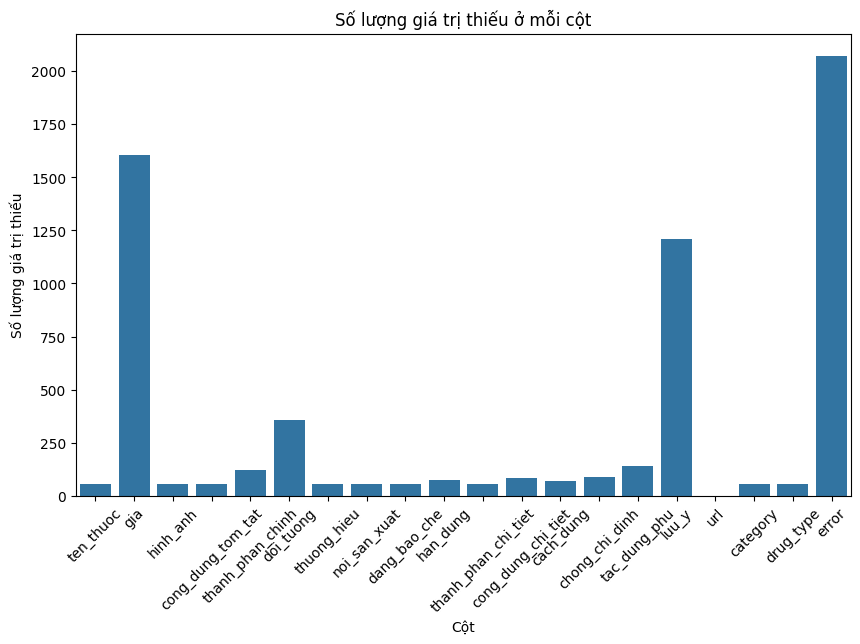

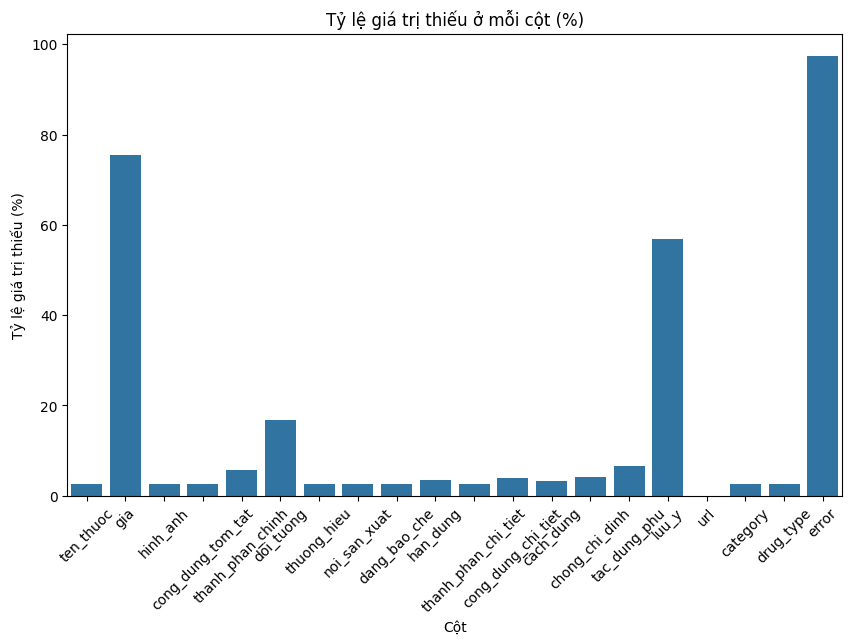

In [38]:
# Vẽ biểu đồ giá trị thiếu theo cột (Số lượng)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Số lượng giá trị thiếu ở mỗi cột')
plt.xlabel('Cột')
plt.ylabel('Số lượng giá trị thiếu')
plt.xticks(rotation=45)
plt.show()


# Vẽ biểu đồ giá trị thiếu theo cột (%)
missing_percent = (missing_values / len(ankhang_df)) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values)
plt.title('Tỷ lệ giá trị thiếu ở mỗi cột (%)')
plt.xlabel('Cột')
plt.ylabel('Tỷ lệ giá trị thiếu (%)')
plt.xticks(rotation=45)
plt.show()

In [39]:
# Các url đang có giá trị NaN
nan_urls = ankhang_df[ankhang_df['url'].isnull()]
print("Các dòng có giá trị NaN ở cột 'url':")
print(nan_urls)

Các dòng có giá trị NaN ở cột 'url':
Empty DataFrame
Columns: [ten_thuoc, gia, hinh_anh, cong_dung_tom_tat, thanh_phan_chinh, doi_tuong, thuong_hieu, noi_san_xuat, dang_bao_che, han_dung, thanh_phan_chi_tiet, cong_dung_chi_tiet, cach_dung, chong_chi_dinh, tac_dung_phu, luu_y, url, category, drug_type, error]
Index: []


In [40]:
ankhang_df = ankhang_df.copy()
# Kiểm tra số lượng dòng bị error (NaN)
error_counts = ankhang_df[ankhang_df['ten_thuoc'].isnull() | ankhang_df['ten_thuoc'].isna()]
print(f"Số dòng bị lỗi: {error_counts.shape[0]}")
print(error_counts)

Số dòng bị lỗi: 54
     ten_thuoc  gia hinh_anh cong_dung_tom_tat thanh_phan_chinh doi_tuong  \
2          NaN  NaN      NaN               NaN              NaN       NaN   
13         NaN  NaN      NaN               NaN              NaN       NaN   
83         NaN  NaN      NaN               NaN              NaN       NaN   
106        NaN  NaN      NaN               NaN              NaN       NaN   
124        NaN  NaN      NaN               NaN              NaN       NaN   
136        NaN  NaN      NaN               NaN              NaN       NaN   
137        NaN  NaN      NaN               NaN              NaN       NaN   
334        NaN  NaN      NaN               NaN              NaN       NaN   
335        NaN  NaN      NaN               NaN              NaN       NaN   
477        NaN  NaN      NaN               NaN              NaN       NaN   
499        NaN  NaN      NaN               NaN              NaN       NaN   
533        NaN  NaN      NaN               NaN           

<h3>Kiểm tra giá trị trùng lặp</h3>

In [41]:
# Kiểm tra giá trị trùng lặp hoàn toàn
duplicate_rows = ankhang_df[ankhang_df.duplicated()]
print("Số lượng các dòng trùng lặp:", duplicate_rows.shape[0])
print("Các dòng trùng lặp:")
print(duplicate_rows)

Số lượng các dòng trùng lặp: 141
Các dòng trùng lặp:
                                              ten_thuoc       gia  \
1969  Timi Roitin trị viêm dây thần kinh, thoái hóa ...  528.000₫   
1970  B Complex C bổ sung vitamin nhóm B và vitamin ...      800₫   
1971                                                NaN       NaN   
1972  Vitamin PP 50 Pharmedic ngăn ngừa thiếu nicoti...   12.000₫   
1973  Agi-Calci bổ sung canxi, trị loãng xương (20 v...  150.000₫   
...                                                 ...       ...   
2105  Ferricure 150mg Capsule trị tình trạng thiếu h...       NaN   
2106  Dung dịch tiêm truyền Glucose 5% Fresenius Kab...       NaN   
2107                                                NaN       NaN   
2108  Moriamin Forte bổ sung acid amin và vitamin (1...       NaN   
2109                                                NaN       NaN   

                                               hinh_anh  \
1969  https://cdn.tgdd.vn/Products/Images/10053/1304...   


In [42]:
# kiểm tra giá trị trung lặp theo URL
pd.set_option('display.max_colwidth', None)
duplicate_urls = ankhang_df[ankhang_df.duplicated(subset=['url'])]
print("Số lượng các dòng có URL trùng lặp:", duplicate_urls.shape[0])
print("Các dòng có URL trùng lặp:")
print(duplicate_urls['url'])


Số lượng các dòng có URL trùng lặp: 158
Các dòng có URL trùng lặp:
1969                         https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/thuoc-bo-sung-vitamin-b-timi-roitin-120-vien?sku=1193668000314
1970                                                          https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/b-complex-c?sku=1193668000204
1971                                           https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/cezinco-110mg-5ml-h-30-ong?sku=1193668000849
1972                                                        https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/vitamin-pp-50?sku=1193687000032
1973                                                     https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/agi-calci-h-200v?sku=1193668000576
                                                                         ...                                                                   
2122                                               https://www.nhathu

In [43]:
pd.reset_option('display.max_colwidth')

In [44]:
# Kiểm tra các giá trị trùng lặp
duplicate_rows = ankhang_df[ankhang_df.duplicated()]
print("Số lượng các dòng trùng lặp:", duplicate_rows.shape[0])
print("Các dòng trùng lặp:")
print(duplicate_rows)


Số lượng các dòng trùng lặp: 141
Các dòng trùng lặp:
                                              ten_thuoc       gia  \
1969  Timi Roitin trị viêm dây thần kinh, thoái hóa ...  528.000₫   
1970  B Complex C bổ sung vitamin nhóm B và vitamin ...      800₫   
1971                                                NaN       NaN   
1972  Vitamin PP 50 Pharmedic ngăn ngừa thiếu nicoti...   12.000₫   
1973  Agi-Calci bổ sung canxi, trị loãng xương (20 v...  150.000₫   
...                                                 ...       ...   
2105  Ferricure 150mg Capsule trị tình trạng thiếu h...       NaN   
2106  Dung dịch tiêm truyền Glucose 5% Fresenius Kab...       NaN   
2107                                                NaN       NaN   
2108  Moriamin Forte bổ sung acid amin và vitamin (1...       NaN   
2109                                                NaN       NaN   

                                               hinh_anh  \
1969  https://cdn.tgdd.vn/Products/Images/10053/1304...   


<h3>Kiểm tra phân bố nhãn</h3>

Số lượng bệnh theo category:
category
Thuốc bổ và vitamin                            434
Kháng sinh, kháng nấm                          257
Giảm đau, hạ sốt, kháng viêm                   215
Thần kinh, não bộ                              210
Tim mạch, tiểu đường, mỡ máu                   201
Da liễu, dị ứng                                200
Tiêu hóa, gan mật                              189
Hô hấp                                         147
Tiết niệu, sinh dục                            104
Cơ xương khớp, gút                              61
Mắt, tai mũi họng                               21
Dầu, Cao Xoa, Miếng Dán                         17
Thuốc điều trị ung thư, miễn dịch               10
Thuốc làm đẹp, giảm cân                          5
Thuốc giải độc, khử độc - hỗ trợ cai nghiện      2
Name: count, dtype: int64


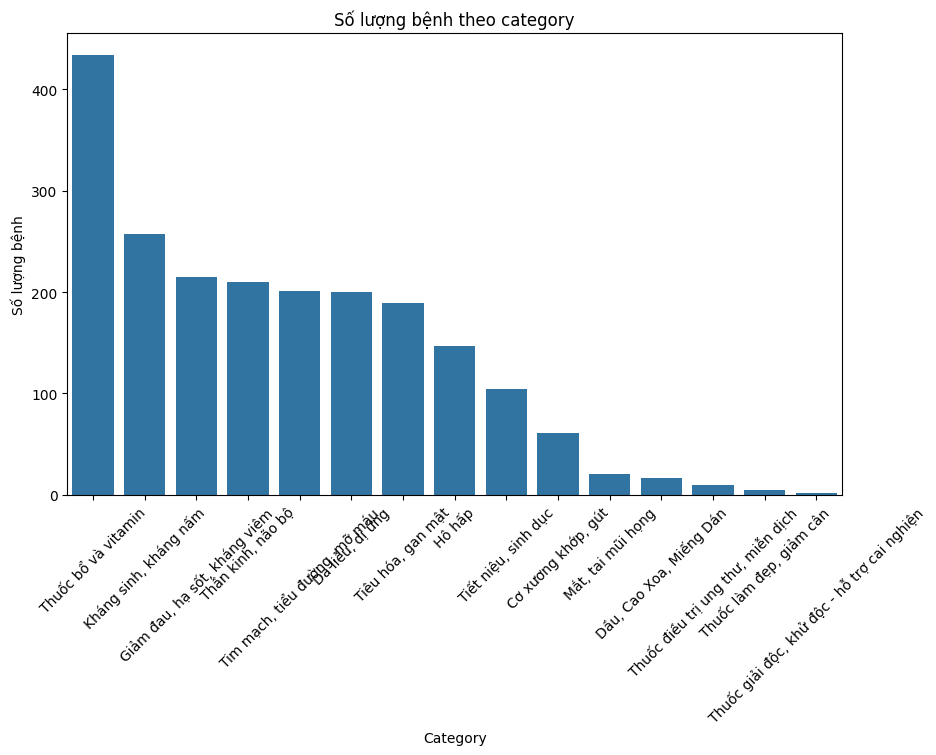

In [46]:
# Kiểm tra số lượng bệnh theo category
category_counts = ankhang_df['category'].value_counts()
print("Số lượng bệnh theo category:")
print(category_counts)


# Vẽ biểu đồ số lượng bệnh theo category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Số lượng bệnh theo category')
plt.xlabel('Category')
plt.ylabel('Số lượng bệnh')
plt.xticks(rotation=45)
plt.show()